# Last.fm bench

Analyze results from `lastfm_batch.ipynb`. Point `BENCH_PATH` at any `lastfm_recommendations_*.csv` file.

In [35]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("../datasets")
BENCH_PATH = DATA_DIR / "lastfm_recommendations_test_random.csv"
RECS_PATH = DATA_DIR / "recommendations_album_level_avg_embeddings.parquet"

## Recommendations


In [36]:
recs = pd.read_parquet(RECS_PATH)

In [39]:
# filtering rank 1 recommendations
recs[recs["rank"] == 1]

# dropping unnecessary columns
recs = recs.drop(columns=["rec_length_flag"])
recs.head(5)


,query_artist,query_album,rec_artist,rec_album,rank,score
0,!!!,as if,off!,off!,1,0.8588
1,!!!,as if,off!,first four eps,2,0.8443
2,!!!,as if,chic,c’est chic,3,0.8403
3,!!!,as if,holy ghost!,holy ghost!,4,0.8352
4,!!!,as if,yeah yeah yeahs,it's blitz!,5,0.8341


## Baseline

In [40]:
df = pd.read_csv(BENCH_PATH)
df["rec_1_score"] = pd.to_numeric(df["rec_1_score"], errors="coerce")

# keep successful recommendations only
df = df[df["status"] == "ok"].reset_index(drop=True)

print(f"File: {BENCH_PATH.name}")
print(f"Strategy: {df['strategy'].iloc[0]}  |  Albums: {len(df):,}")
df.head(5)

File: lastfm_recommendations_test_random.csv
Strategy: random  |  Albums: 157


,album_id,artist,album,review_count,strategy,status,error,seed_track,rec_1_album,rec_1_artist,rec_1_score
0,2387,Beres Hammond,"One Love, One Life",1,random,ok,NaN,Don't You Feel Like Dancing,Solitary Red Rose,Glen Washington,0.944751
1,9855,Guided by Voices,Suitcase: Failed Experiments and Trashed Aircraft,1,random,ok,NaN,Long Way To Run,"1996-07-23: Sudsy Malone's, Cincinnati, OH, USA",Neutral Milk Hotel,0.271151
2,12100,John Butcher,13 Friendly Numbers,1,random,ok,NaN,Mackle Music,Impropositions,Mats Gustafsson,0.785727
3,15294,Maria Minerva,Histrionic,1,random,ok,NaN,Galaxy,Rainbow Edition,Hype Williams,0.163881
4,30289,Young Thug,So Much Fun,1,random,ok,NaN,Lil Baby,Hip Hop Summer Party,Lil Uzi Vert,0.235293


In [41]:
baseline = df.rename(columns={
    "artist":       "query_artist",
    "album":        "query_album",
    "rec_1_artist": "rec_artist",
    "rec_1_album":  "rec_album",
    "rec_1_score":  "score",
})[["query_artist", "query_album", "rec_artist", "rec_album", "score"]].copy()
baseline["rank"] = 1

print(f"Baseline rows: {len(baseline):,}")
baseline.head(3)

Baseline rows: 157


,query_artist,query_album,rec_artist,rec_album,score,rank
0,Beres Hammond,"One Love, One Life",Glen Washington,Solitary Red Rose,0.944751,1
1,Guided by Voices,Suitcase: Failed Experiments and Trashed Aircraft,Neutral Milk Hotel,"1996-07-23: Sudsy Malone's, Cincinnati, OH, USA",0.271151,1
2,John Butcher,13 Friendly Numbers,Mats Gustafsson,Impropositions,0.785727,1


# Comparisons

## Repeated Albums

In [43]:
def repeated_albums(df, label, rec_col="rec_album"):
    counts = df[rec_col].str.strip().str.lower().value_counts()
    n_total = len(df)
    n_unique = counts.size
    n_repeated = (counts > 1).sum()
    print(f"[{label}]")
    print(f"  Total:    {n_total:,}")
    print(f"  Unique:   {n_unique:,}  ({n_unique / n_total:.1%})")
    print(f"  Repeated: {n_repeated:,}  ({n_repeated / n_unique:.1%} of unique)")
    # if n_repeated:
    #     print()
    #     display(
    #         counts[counts > 1]
    #         .rename("count")
    #         .to_frame()
    #         .assign(rec_album=lambda d: d.index)[["rec_album", "count"]]
    #     )
    print()


repeated_albums(recs[recs["rank"] == 1], "embedding recs")
repeated_albums(baseline, "last.fm baseline")

[embedding recs]
  Total:    44,716
  Unique:   17,889  (40.0%)
  Repeated: 9,036  (50.5% of unique)

[last.fm baseline]
  Total:    157
  Unique:   157  (100.0%)
  Repeated: 0  (0.0% of unique)



## Score distribution

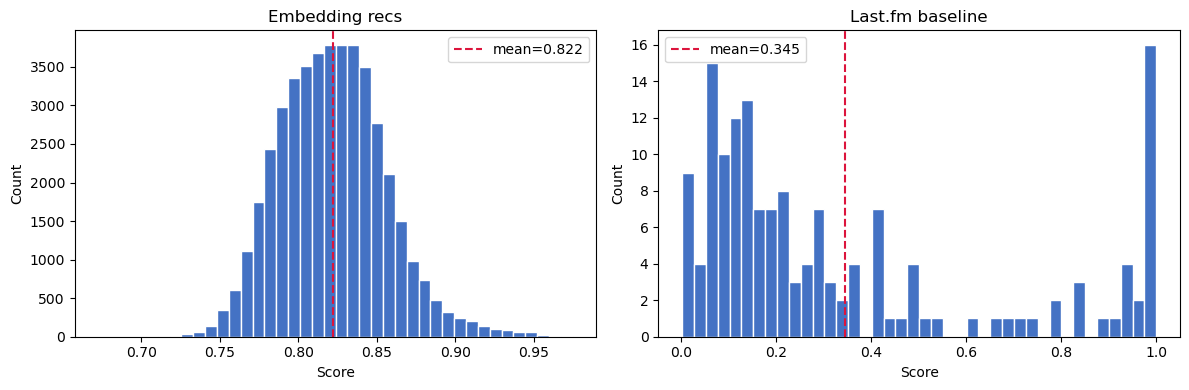

In [47]:
import matplotlib.pyplot as plt

def score_distribution(df, label, score_col="score"):
    s = df[score_col].dropna()
    # print(f"[{label}]")
    # print(s.describe().round(3).to_string())
    # print()
    return s


s_recs = score_distribution(recs[recs["rank"] == 1], "embedding recs")
s_base = score_distribution(baseline, "last.fm baseline")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, s, label in zip(axes, [s_recs, s_base], ["Embedding recs", "Last.fm baseline"]):
    ax.hist(s, bins=40, color="#4472C4", edgecolor="white")
    ax.axvline(s.mean(), color="crimson", ls="--", label=f"mean={s.mean():.3f}")
    ax.set(title=label, xlabel="Score", ylabel="Count")
    ax.legend()
plt.tight_layout()
plt.show()

In [48]:
## Reciprocity

In [49]:
def reciprocity(df, label):
    """If A recommends B, does B recommend A back?"""
    norm = lambda s: s.str.strip().str.lower()
    edges = set(zip(norm(df["query_artist"]) + "::" + norm(df["query_album"]),
                    norm(df["rec_artist"])   + "::" + norm(df["rec_album"])))
    reciprocal = sum(1 for a, b in edges if (b, a) in edges)
    rate = reciprocal / len(edges) if edges else 0
    print(f"[{label}]")
    print(f"  Edges:       {len(edges):,}")
    print(f"  Reciprocal:  {reciprocal:,}")
    print(f"  Rate:        {rate:.1%}")
    print()


reciprocity(recs[recs["rank"] == 1], "embedding recs")
reciprocity(baseline, "last.fm baseline")

[embedding recs]
  Edges:       44,716
  Reciprocal:  9,126
  Rate:        20.4%

[last.fm baseline]
  Edges:       157
  Reciprocal:  0
  Rate:        0.0%

